# Text Mining and Word Cloud

This notebook demonstrates basic text mining techniques using Python on a sample speech dataset. It focuses on cleaning and transforming unstructured text into a structured format for analysis. The results are visualized using word frequency outputs and a word cloud to highlight key themes in the text.

##### Import Libraries and Load Data

This section imports the required Python libraries for text mining and visualization. It then loads the dataset (Martin Luther King Jr.’s speech) from an online source into the workspace for analysis.

In [11]:
# Import libraries
import re
import requests
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import nltk

# Download stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords

print("All libraries loaded successfully.")

All libraries loaded successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dhrumil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
# Load data
url = "http://www.sthda.com/sthda/RDoc/example-files/martin-luther-king-i-have-a-dream-speech.txt"
response = requests.get(url)
text = response.text

##### Text Preprocessing

This step cleans and prepares the text for analysis by converting it to lowercase, removing numbers, punctuation, and extra spaces, and filtering out common stopwords. These transformations standardize the data and reduce noise.

In [13]:
# Replace specific characters with space (/, @, |)
text = re.sub(r"[\/@\|]", " ", text)

# Convert to lowercase
text = text.lower()

# Remove numbers
text = re.sub(r"\d+", "", text)

# Remove punctuation
text = re.sub(r"[^\w\s]", "", text)

# Remove extra whitespace
text = re.sub(r"\s+", " ", text).strip()

##### Tokenization and Stopword Removal

The cleaned text is split into individual words (tokens). Common and irrelevant words (stopwords) are removed to retain only meaningful terms for analysis.

In [14]:
# Define stopwords
stop_words = set(stopwords.words("english"))

# Custom stopwords
custom_stopwords = {"blabla1", "blabla2"}
stop_words = stop_words.union(custom_stopwords)

# Tokenize
words = text.split()

# Filter words
filtered_words = [word for word in words if word not in stop_words]

##### Term Frequency Calculation

This section calculates how often each word appears in the text. The results are stored in a structured format and sorted to identify the most frequent terms.

In [15]:
# Count word frequencies
word_freq = Counter(filtered_words)

# Convert to DataFrame
df = pd.DataFrame(word_freq.items(), columns=["word", "freq"])
df = df.sort_values(by="freq", ascending=False)

# Display top 10
print(df.head(10))

         word  freq
46    freedom    13
127      ring    12
126       let    11
7       dream    11
12        day    11
74      every     9
11        one     8
33       able     8
35   together     7
13     nation     4


##### Word Cloud Visualization

A word cloud is generated to visually represent word frequency. Words that appear more often are displayed in larger sizes, highlighting key themes in the text.

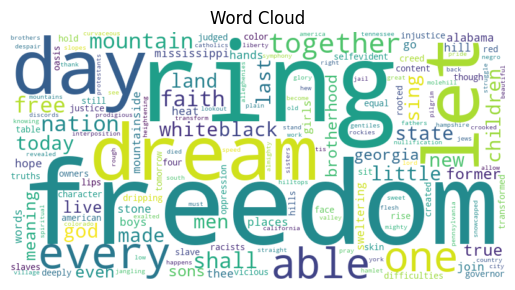

In [31]:
# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    max_words=200,
    background_color="white"
).generate_from_frequencies(word_freq)

wordcloud.to_file("wordcloud.png")

plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

##### Frequent Terms Extraction

This step filters and displays words that occur above a specified frequency threshold, helping to focus on the most significant terms in the dataset.

In [20]:
# Filter frequent terms
lowfreq = 4
frequent_terms = {word: freq for word, freq in word_freq.items() if freq >= lowfreq}

print("\nFrequent terms (freq >= 4):")
print(dict(sorted(frequent_terms.items(), key=lambda x: x[1], reverse=True)))


Frequent terms (freq >= 4):
{'freedom': 13, 'ring': 12, 'dream': 11, 'day': 11, 'let': 11, 'every': 9, 'one': 8, 'able': 8, 'together': 7, 'nation': 4, 'shall': 4, 'mountain': 4, 'faith': 4, 'free': 4}


##### Word Association Analysis

This section identifies words that frequently appear alongside a selected term which provide insight into relationships and contextual meaning within the text.

In [22]:
# Find associations with a target word
target_word = "freedom"
sentences = re.split(r'[.!?]', text)

co_occurrence = Counter()

for sentence in sentences:
    tokens = sentence.split()
    if target_word in tokens:
        for token in tokens:
            if token != target_word and token not in stop_words:
                co_occurrence[token] += 1

# Filter associations
assoc_threshold = 3
associations = {word: count for word, count in co_occurrence.items() if count >= assoc_threshold}

print(f"\nAssociations with '{target_word}':")
print(dict(sorted(associations.items(), key=lambda x: x[1], reverse=True)))


Associations with 'freedom':
{'ring': 12, 'dream': 11, 'day': 11, 'let': 11, 'every': 9, 'one': 8, 'able': 8, 'together': 7, 'nation': 4, 'shall': 4, 'mountain': 4, 'faith': 4, 'free': 4, 'today': 3, 'men': 3, 'state': 3, 'little': 3, 'children': 3, 'black': 3, 'white': 3, 'made': 3, 'god': 3, 'sing': 3, 'new': 3, 'land': 3, 'last': 3}


##### Bar Plot of Top Words

A bar chart is created to display the top 10 most frequent words which offers a clear comparison of their frequencies.

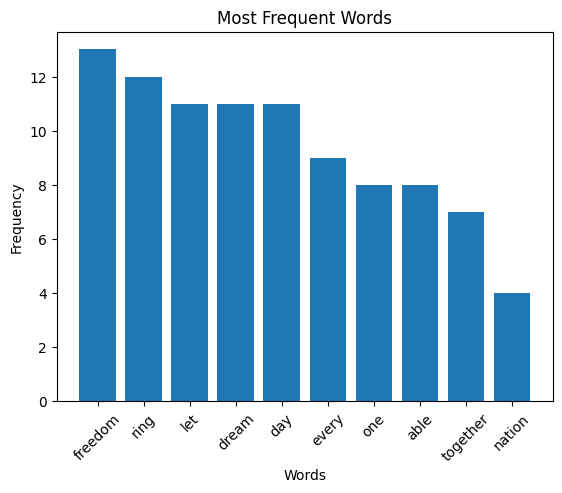

In [23]:
# Plot top 10 words
top10 = df.head(10)

plt.figure()
plt.bar(top10["word"], top10["freq"])
plt.xticks(rotation=45)
plt.title("Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()